# Define the problem

Import libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

Data collection

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/Phionanamugga/teaching/refs/heads/main/datasets/mnist.csv')

Data exploration

In [3]:
print(df.head())
print(df.info())
print(df.describe())

      id  class  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0  31953      5       0       0       0       0       0       0       0   
1  34452      8       0       0       0       0       0       0       0   
2  60897      5       0       0       0       0       0       0       0   
3  36953      0       0       0       0       0       0       0       0   
4   1981      3       0       0       0       0       0       0       0   

   pixel8  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0         0         0     

Data processing and feature engineering

In [4]:
X = df.drop('class', axis=1)
y = df['class']

scaler = StandardScaler()
X = scaler.fit_transform(X)

Split dataset

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Train model

In [6]:
svm_model = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)

SVC(C=1, random_state=42)

Model evaluation

In [7]:
y_pred = svm_model.predict(X_test)
print("\nModel Evaluation:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


Model Evaluation:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98        70
           1       0.94      0.97      0.96       100
           2       0.74      0.90      0.81        73
           3       0.94      0.91      0.92        86
           4       0.90      0.96      0.93        80
           5       0.85      0.91      0.88        64
           6       0.98      0.90      0.94        90
           7       0.98      0.94      0.96        67
           8       0.94      0.86      0.90        94
           9       0.93      0.84      0.88        76

    accuracy                           0.92       800
   macro avg       0.92      0.92      0.92       800
weighted avg       0.92      0.92      0.92       800

Accuracy: 0.91625


Plotting confusion matrix

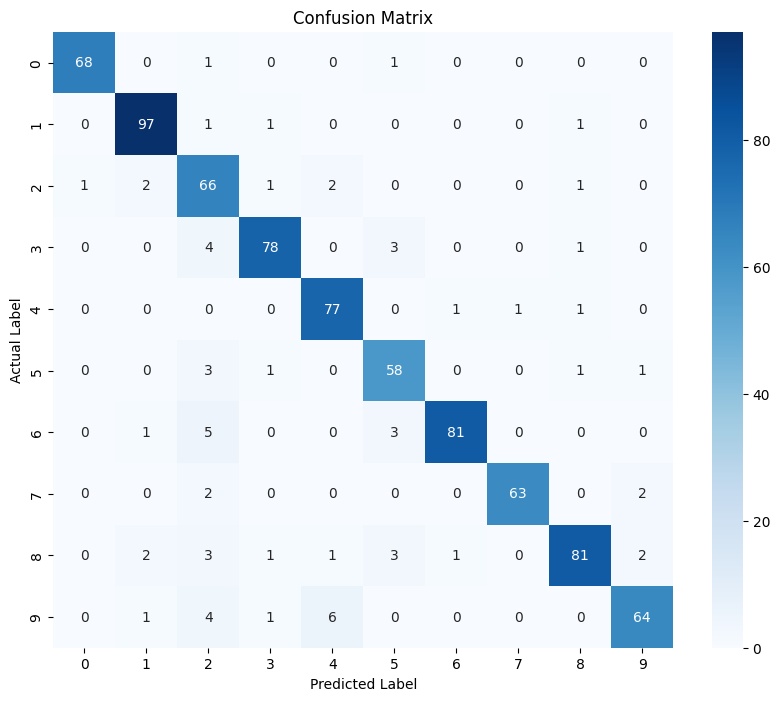

In [8]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()